In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/coil100")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'coil100' dataset.
Path to dataset files: /kaggle/input/coil100


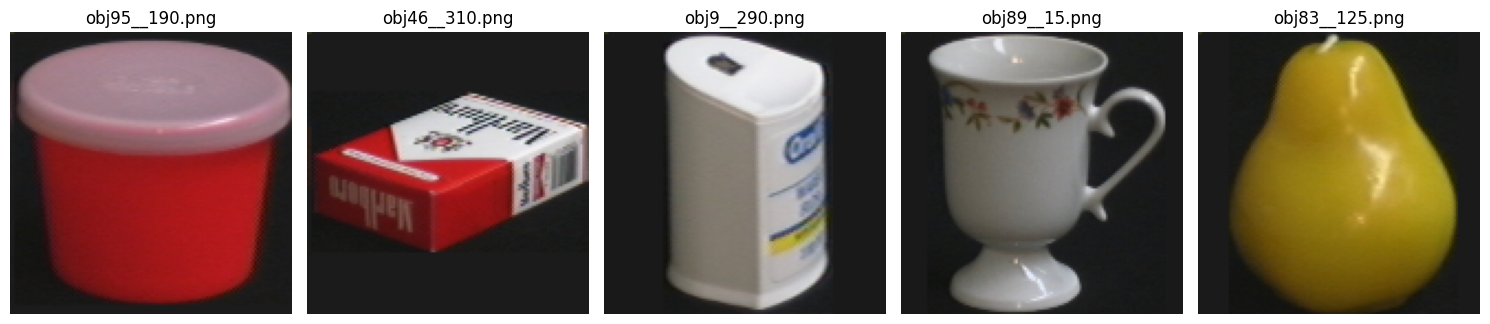

In [19]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
/kaggle/input/coil100
dataset_path = ""

# Collect all image paths
image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# Randomly select 5 images
sample_images = random.sample(image_paths, 5)

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
import os
import pandas as pd
from PIL import Image
import numpy as np

dataset_path = "/kaggle/input/coil100"

data = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            img_path = os.path.join(root, file)

            try:
                with Image.open(img_path) as img:
                    img_array = np.array(img)

                    if len(img_array.shape) == 2:
                        height, width = img_array.shape
                        channels = 1
                    else:
                        height, width = img_array.shape[:2]
                        channels = img_array.shape[2]

                    data.append({
                        "Filename": file,
                        "Path": img_path,
                        "Height": height,
                        "Width": width,
                        "Channels": channels
                    })

            except Exception as e:
                print(f"Error reading {img_path}: {e}")

df = pd.DataFrame(data)

print("Total images processed:", len(df))

# Show all rows (be careful for very large datasets)
display(df)

# Save table
df.to_csv("image_metadata.csv", index=False)

Total images processed: 7200


,Filename,Path,Height,Width,Channels
0,obj7__160.png,/kaggle/input/coil100/coil-100/coil-100/obj7__...,128,128,3
1,obj91__95.png,/kaggle/input/coil100/coil-100/coil-100/obj91_...,128,128,3
2,obj56__230.png,/kaggle/input/coil100/coil-100/coil-100/obj56_...,128,128,3
3,obj95__230.png,/kaggle/input/coil100/coil-100/coil-100/obj95_...,128,128,3
4,obj1__255.png,/kaggle/input/coil100/coil-100/coil-100/obj1__...,128,128,3
...,...,...,...,...,...
7195,obj22__125.png,/kaggle/input/coil100/coil-100/coil-100/obj22_...,128,128,3
7196,obj21__245.png,/kaggle/input/coil100/coil-100/coil-100/obj21_...,128,128,3
7197,obj15__185.png,/kaggle/input/coil100/coil-100/coil-100/obj15_...,128,128,3
7198,obj14__145.png,/kaggle/input/coil100/coil-100/coil-100/obj14_...,128,128,3


In [32]:
import os
from PIL import Image

input_dir = "YOUR_DATASET_PATH"
output_dir = "/content/resized_dataset"

os.makedirs(output_dir, exist_ok=True)

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            input_path = os.path.join(root, file)

            # Preserve folder structure
            relative_path = os.path.relpath(root, input_dir)
            save_folder = os.path.join(output_dir, relative_path)
            os.makedirs(save_folder, exist_ok=True)

            output_path = os.path.join(save_folder, file)

            try:
                img = Image.open(input_path)
                img = img.resize((224, 224))
                img.save(output_path)

            except Exception as e:
                print(f"Error processing {input_path}: {e}")

print("All images resized to 224×224 and saved.")

All images resized to 224×224 and saved.


In [33]:
import os
from PIL import Image

input_dir = "YOUR_DATASET_PATH"

gray_dir = "/content/grayscale_images"
rgb_dir = "/content/rgb_images"
hsv_dir = "/content/hsv_images"

os.makedirs(gray_dir, exist_ok=True)
os.makedirs(rgb_dir, exist_ok=True)
os.makedirs(hsv_dir, exist_ok=True)

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):

            img_path = os.path.join(root, file)

            try:
                img = Image.open(img_path)

                # Grayscale
                gray_img = img.convert("L")
                gray_img.save(os.path.join(gray_dir, file))

                # RGB
                rgb_img = img.convert("RGB")
                rgb_img.save(os.path.join(rgb_dir, file))

                # HSV
                hsv_img = rgb_img.convert("HSV")
                hsv_img.save(os.path.join(hsv_dir, file))

            except Exception as e:
                print(f"Error processing {file}: {e}")

print("Conversion completed.")

Conversion completed.


In [37]:
import os
import numpy as np
from PIL import Image

dataset_path = "/kaggle/input/coil100"

normalized_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            img_path = os.path.join(root, file)

            try:
                img = Image.open(img_path).convert("RGB")  # ensure consistent shape
                img_array = np.array(img)

                # Normalize
                img_norm = img_array / 255.0

                normalized_images.append(img_norm)

            except Exception as e:
                print(f"Error: {img_path} -> {e}")

print("Total normalized images:", len(normalized_images))

Total normalized images: 7200


In [39]:
import os
import tensorflow as tf

dataset_path = "/kaggle/input/coil100"

image_paths = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, file))

print("Total images:", len(image_paths))

Total images: 7200


In [40]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32) / 255.0  # normalize
    return img

In [46]:
def augment(img):
    aug = {}

    # Rotation (90 degrees)
    aug["rotation"] = tf.image.rot30(img)

    # Horizontal flip
    aug["flip"] = tf.image.flip_left_right(img)

    # Zoom (center crop + resize)
    cropped = tf.image.central_crop(img, central_fraction=0.7)
    aug["zoom"] = tf.image.resize(cropped, (224, 224))

    # Brightness adjustment
    aug["brightness"] = tf.image.adjust_brightness(img, delta=0.3)

    return aug

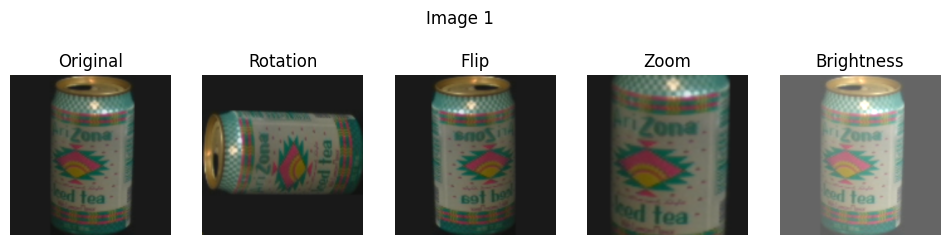

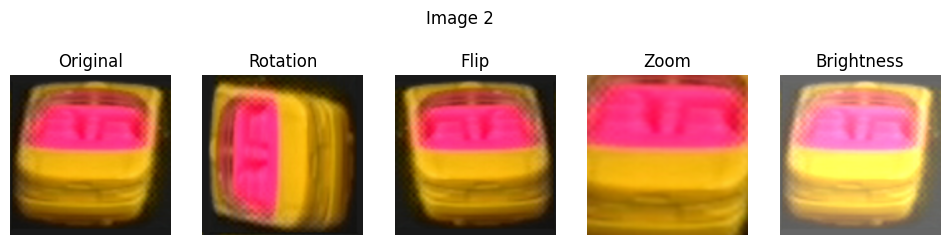

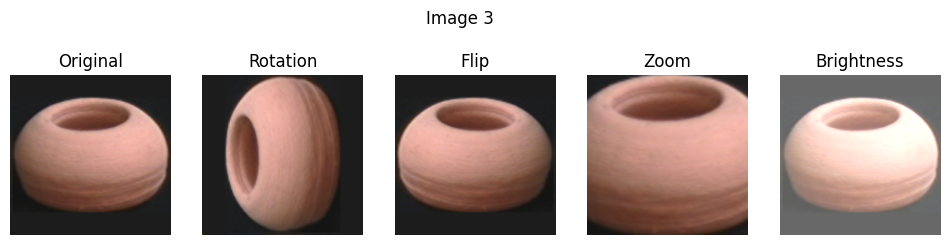

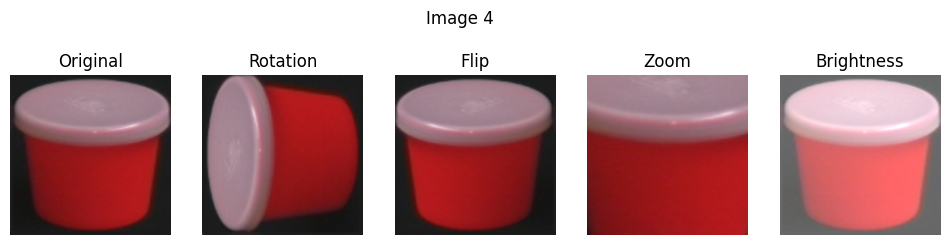

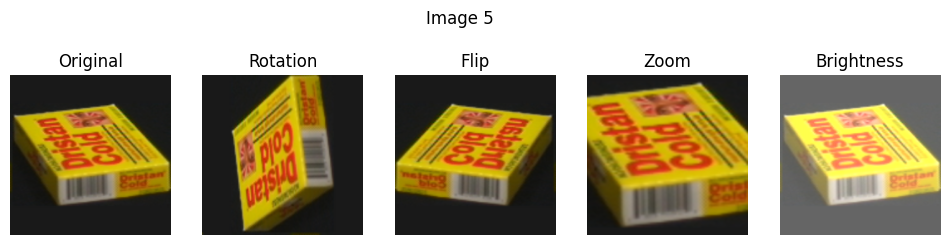

In [48]:
import matplotlib.pyplot as plt
import tensorflow as tf

def augment(img):
    aug = {}

    # Rotation (90 degrees)
    aug["rotation"] = tf.image.rot90(img, k=1)

    # Horizontal flip
    aug["flip"] = tf.image.flip_left_right(img)

    # Zoom (center crop + resize)
    cropped = tf.image.central_crop(img, central_fraction=0.7)
    aug["zoom"] = tf.image.resize(cropped, (224, 224))

    # Brightness adjustment
    aug["brightness"] = tf.image.adjust_brightness(img, delta=0.3)

    return aug

for i, path in enumerate(image_paths[:5]):
    img = load_image(path)
    aug = augment(img)

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 5, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    # Clip values to [0, 1] before displaying to avoid warnings
    plt.subplot(1, 5, 2)
    plt.imshow(tf.clip_by_value(aug["rotation"], 0.0, 1.0))
    plt.title("Rotation")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(tf.clip_by_value(aug["flip"], 0.0, 1.0))
    plt.title("Flip")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(tf.clip_by_value(aug["zoom"], 0.0, 1.0))
    plt.title("Zoom")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(tf.clip_by_value(aug["brightness"], 0.0, 1.0))
    plt.title("Brightness")
    plt.axis("off")

    plt.suptitle(f"Image {i+1}")
    plt.show()

In [49]:
import tensorflow as tf

def preprocess_image(image_path, img_size=(224, 224)):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

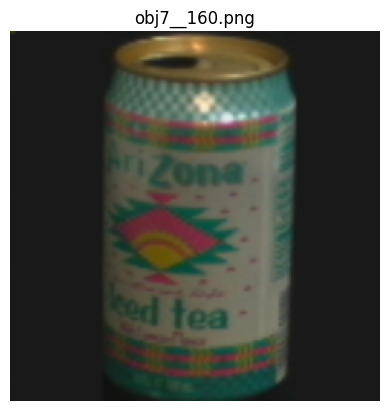

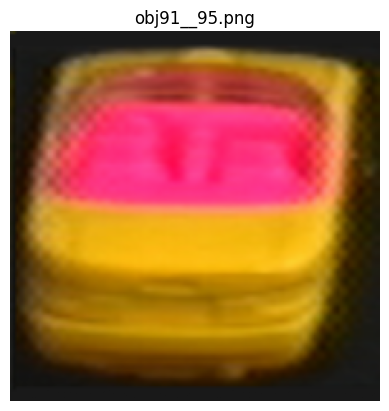

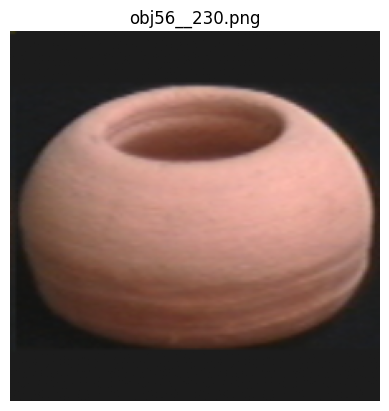

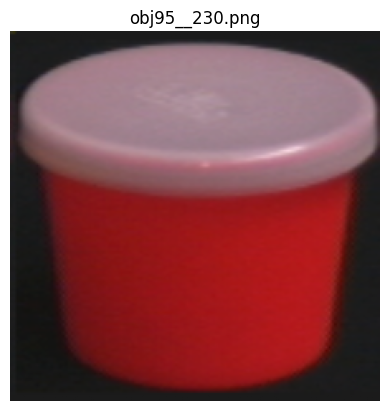

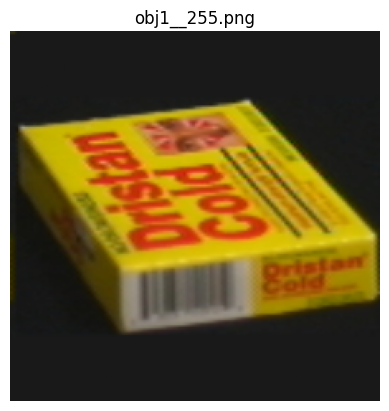

In [50]:
import os

dataset_path = "/kaggle/input/coil100"

for root, _, files in os.walk(dataset_path):
    for file in files[:5]:  # first 5 images
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)

            img = preprocess_image(path)

            plt.imshow(img)
            plt.title(file)
            plt.axis("off")
            plt.show()